In [1]:
import numpy as np 
import math
import matplotlib.pyplot as plt 
%matplotlib  inline 

In [2]:
def f(x): 
    return 5*x**2 - 7*x+2



why are we doing this?

Micrograd is about understanding **derivatives and gradients**.

We first need a mathematical function so that we can later calculate its derivative and see how Micrograd performs automatic differentiation.
    

In [3]:
f(3)

26

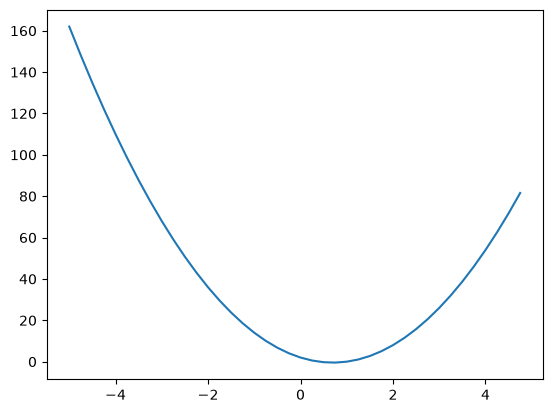

In [4]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
plt.plot(xs,ys)

Why are we doing this?

We want to **visualize the function** before working with derivatives and Micrograd.

Later, we will use similar functions to understand how changing an input affects the output.


In [5]:
h = 0.000000001
x = 3
(f(x+h)-f(x))/h


23.000001903028533

In [6]:
h = 0.000000001
x = 7/10
(f(x+h)-f(x))/h

0.0

In [7]:
# lets get some more complex data 
a = 4.0
b = -5.0
c = 25 

d = a*b + c
print(d)


5.0


In [8]:
h = 0.00001

# inputs 
a = 4.0
b = -5.0
c = 25 

d1 = a*b + c
a = a+h
d2 = a*b + c

print("d1",d1)
print("d2",d2)
print("slope",(d2-d1)/h)

d1 5.0
d2 4.999950000000002
slope -4.999999999810711


In [9]:
h = 0.00001

# inputs 
a = 4.0
b = -5.0
c = 25 

d1 = a*b + c
b = b+h
d2 = a*b + c

print("d1",d1)
print("d2",d2)
print("slope",(d2-d1)/h)

d1 5.0
d2 5.0000399999999985
slope 3.9999999998485687


In [10]:
class value :
    def __init__(self,data):
        self.data = data 
    def __repr__(self):
        return f"value(data={self.data})"    # data is a number 


    def __add__(self,other): # doing it becoz python does not know how to add two values 
        out = value(self.data + other.data)   
        return out 

    # simillarly doing for multiplication 
    def __mul__(self,other):
        out = value(self.data * other.data)
        return out    

a = value(4.0)      
b = value(-5.0)
c = value(25)
d = a*b+c # it will internally calls like : (a.__mul__(b)).__add__(c)
d

value(data=5.0)

# ##. Creating the `Value` Class

## Code

    class Value:
        def __init__(self, data):
            self.data = data

        def __repr__(self):
            return f"Value(data={self.data})"

## What are we doing?

We are creating a class called `Value`.

This class will become the **basic building block of Micrograd**.

Instead of working with normal numbers like:

    a = 4.0

Micrograd will eventually use:

    a = Value(4.0)

The `Value` object will later store not only the number, but also information needed for **gradients and backpropagation**.

---

## 1. `class Value:`

    class Value:

`class` is used to create a new type of object.

Here, we create our own type called `Value`.

Think of it as a container that will hold a number and, later, its gradient and other information.

---

## 2. `__init__()`

    def __init__(self, data):

`__init__()` is a special Python method.

It runs automatically when we create a new `Value`.

For example:

    a = Value(4.0)

Python automatically calls:

    __init__(self, 4.0)

---

## 3. `self.data = data`

    self.data = data

This stores the actual numerical value inside the `Value` object.

For example:

    a = Value(4.0)

Then:

    a.data

gives:

    4.0

So:

    Value object
        ↓
    data = 4.0

---

## 4. `__repr__()`

    def __repr__(self):
        return f"Value(data={self.data})"

`__repr__()` controls how the object is displayed when we print it or inspect it.

For example:

    a = Value(4.0)

Without `__repr__()`, Python may display something like:

    <Value object at 0x...>

With `__repr__()`, it displays:

    Value(data=4.0)

This makes the object easier to understand while developing Micrograd.

---

## 5. Why `__init__` and `__repr__` have double underscores?

These are Python **special methods**, also called **dunder methods**.

`dunder` means:

    double underscore

Therefore, the correct names are:

    __init__()
    __repr__()

NOT:

    _init_()
    _repr_()

---

## Example

    a = Value(4.0)

Now:

    a.data

returns:

    4.0

And:

    print(a)

displays:

    Value(data=4.0)

---

## Why are we creating `Value`?

Currently, `Value` only stores a number.

But later we will expand it to store:

    Value
      ├── data
      ├── gradient
      ├── previous values
      └── operation

This information will allow Micrograd to build a **computation graph** and perform **backpropagation automatically**.

## Key Takeaway

`Value` is the basic object of Micrograd.

For now, it simply stores a number:

    Value(4.0)
        ↓
    data = 4.0

Later, we will add everything needed to calculate gradients automatically.

In [11]:
# more clearler visulization :

class value :
    def __init__(self,data, _children=(),_op='',label=''):
        self.data = data 
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0
    def __repr__(self):
        return f"value(data={self.data})"    # data is a number 


    def __add__(self,other): # doing it becoz python does not know how to add two values 
        out = value(self.data + other.data,(self,other),'+')   
        return out 

    # simillarly doing for multiplication 
    def __mul__(self,other):
        out = value(self.data * other.data,(self,other),'*')
        return out    

# Activating tanh() function 
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = value(t, (self,), 'tanh')
        return out

    # def _backward():
    #     self.grad += (1 - t**2) * out.grad
    #     out._backward = _backward
    #     return out

a = value(4.0,label = 'a')      
b = value(-5.0,label = 'b')
c = value(25, label ='c')

e= a*b ; e.label = 'e'

d = e +c ; d.label = 'd' # it will internally calls like : (a.__mul__(b)).__add__(c)
f = value(-2.0,label ='f')
L = d*f ; L.label = 'L'
L

value(data=-10.0)

# Complete Explanation — Building a Computation Graph in Micrograd

This code creates a custom `value` class that can:

1. Store numbers.
2. Remember previous values.
3. Remember which operation created a value.
4. Store labels for visualization.
5. Store a place for gradients.
6. Perform addition and multiplication between `value` objects.

---

# 1. Creating the `value` class

    class value:

We create our own class called `value`.

Instead of working directly with normal Python numbers like:

    a = 4.0

we will use:

    a = value(4.0)

This allows us to store not only the number but also information about how it was calculated.

---

# 2. The `__init__()` function

    def __init__(self, data, _children=(), _op='', label=''):

`__init__()` runs automatically whenever we create a new `value`.

For example:

    a = value(4.0, label='a')

The arguments are:

    data       → actual numerical value
    _children  → previous values used to create this value
    _op        → operation used to create this value
    label      → name of the value

The default values are:

    _children = ()
    _op = ''
    label = ''

This means we don't have to provide them every time.

---

# 3. `self.data`

    self.data = data

Stores the actual numerical value.

For example:

    a = value(4.0)

Then:

    a.data

is:

    4.0

Similarly:

    b = value(-5.0)

means:

    b.data = -5.0

---

# 4. `self._prev`

    self._prev = set(_children)

`_prev` stores the values that were used to create the current value.

For example, when we calculate:

    e = a * b

`e` was created using `a` and `b`.

Therefore:

    e._prev

contains:

    {a, b}

Why do we need this?

Because later Micrograd needs to know the previous values so it can move **backward through the computation graph** during backpropagation.

`set()` is used so that the values are stored as a unique collection.

---

# 5. `self._op`

    self._op = _op

Stores the operation that created the value.

For example:

    e = a * b

Then:

    e._op

is:

    '*'

For:

    d = e + c

we have:

    d._op

as:

    '+'

So Micrograd knows what operation produced each value.

---

# 6. `self.label`

    self.label = label

Stores a name for the value.

For example:

    a = value(4.0, label='a')

Then:

    a.label

is:

    'a'

The label is mainly useful when **visualizing the computation graph**.

---

# 7. `self.grad`

    self.grad = 0.0

Creates a variable to store the gradient of this value.

Currently, we are not calculating gradients yet, so every gradient starts at:

    0.0

Later, during backpropagation, these values will be updated.

---

# 8. `__repr__()` function

    def __repr__(self):
        return f"value(data={self.data})"

`__repr__()` controls how our object is displayed in Python.

For example:

    a = value(4.0)

If we write:

    a

Python displays:

    value(data=4.0)

instead of showing a confusing object address.

---

# 9. `__add__()` — defining addition

    def __add__(self, other):

This function tells Python how to add two `value` objects.

Normally Python knows how to do:

    4 + 5

But Python does not automatically know how to do:

    value(4) + value(5)

So we define `__add__()` ourselves.

---

# 10. Inside `__add__()`

    out = value(self.data + other.data, (self, other), '+')

Let's break this down.

Suppose:

    a = value(4.0)
    b = value(-5.0)

and we write:

    e = a + b

Here:

    self = a
    other = b

So:

    self.data = 4.0
    other.data = -5.0

The calculation becomes:

    4.0 + (-5.0) = -1.0

A new `value` object is created:

    out = value(-1.0, (a, b), '+')

This new value remembers:

    data      = -1.0
    children  = a, b
    operation = +

---

# 11. Returning `out`

    return out

The newly created value is returned.

So:

    e = a + b

means `e` receives the new `value` object.

---

# 12. `__mul__()` — defining multiplication

    def __mul__(self, other):

This function tells Python how to multiply two `value` objects.

Normally:

    4 * 5

works automatically.

But:

    value(4) * value(5)

needs our custom `__mul__()` function.

---

# 13. Inside `__mul__()`

    out = value(self.data * other.data, (self, other), '*')

Suppose:

    a = value(4.0)
    b = value(-5.0)

Then:

    a * b

becomes:

    4.0 * (-5.0) = -20.0

A new value is created:

    out = value(-20.0, (a, b), '*')

So `out` remembers:

    data      = -20.0
    children  = a, b
    operation = *

---

# 14. Creating `a`, `b`, and `c`

    a = value(4.0, label='a')
    b = value(-5.0, label='b')
    c = value(25, label='c')

We create three input values:

    a = 4
    b = -5
    c = 25

Their labels are:

    a → 'a'
    b → 'b'
    c → 'c'

---

# 15. Creating `e`

    e = a * b
    e.label = 'e'

First:

    a * b

calls:

    a.__mul__(b)

Calculation:

    4 × (-5) = -20

Therefore:

    e.data = -20

And `e` remembers:

    e._prev = {a, b}
    e._op = '*'
    e.label = 'e'

The graph is:

    a (4) ──┐
            × ──> e (-20)
    b (-5) ─┘

---

# 16. Creating `d`

    d = e + c
    d.label = 'd'

First:

    e + c

calls:

    e.__add__(c)

Calculation:

    -20 + 25 = 5

Therefore:

    d.data = 5

And `d` remembers:

    d._prev = {e, c}
    d._op = '+'
    d.label = 'd'

Now the graph is:

    a ──┐
        × ──> e ──┐
    b ──┘         + ──> d
                  │
    c ────────────┘

---

# 17. Creating `f`

    f = value(-2.0, label='f')

We create another input:

    f = -2

with the label:

    'f'

---

# 18. Creating the final output `L`

    L = d * f
    L.label = 'L'

Now:

    d = 5
    f = -2

So:

    L = 5 × (-2)
    L = -10

Therefore:

    L.data = -10

The final computation graph is:

    a (4) ──┐
            × ──> e (-20) ──┐
    b (-5) ─┘               +
                            ├──> d (5) ──┐
    c (25) ─────────────────┘           × ──> L (-10)
                                        │
    f (-2) ─────────────────────────────┘

---

# 19. What does this comment mean?

    d = e + c  # it will internally calls like:
               # (a.__mul__(b)).__add__(c)

The original expression:

    d = e + c

is actually based on the earlier calculation:

    e = a * b

So the complete calculation is:

    d = (a * b) + c

Python roughly performs:

    e = a.__mul__(b)
    d = e.__add__(c)

Then:

    L = d * f

uses:

    d.__mul__(f)

---

# 20. Final calculation

The mathematical expression represented by the code is:

    L = (a × b + c) × f

Substituting the values:

    L = (4 × -5 + 25) × -2

    L = (-20 + 25) × -2

    L = 5 × -2

    L = -10

So:

    L.data

gives:

    -10.0

---

# 21. The most important idea

The class is doing more than simply calculating numbers.

It is creating a **computation graph**.

Each value remembers:

    data → what is the value?
    _prev → which values created it?
    _op → which operation created it?
    label → what should we call it?
    grad → where will we store its gradient?

The graph is:

    a ──┐
        × ──> e ──┐
    b ──┘         │
                  + ──> d ──┐
    c ────────────┘         │
                            × ──> L
    f ──────────────────────┘

This graph is the foundation of **automatic differentiation**.

## Key Takeaway

The code calculates:

    L = (a × b + c) × f = -10

But more importantly, it **remembers every step used to calculate -10**.

That stored calculation history will allow Micrograd to later calculate gradients automatically using **backpropagation**.

In [12]:
L._prev

{value(data=-2.0), value(data=5.0)}

In [13]:
L._op

'*'

## # graphical representation 

graphviz is open source graph visualization software 

In [14]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

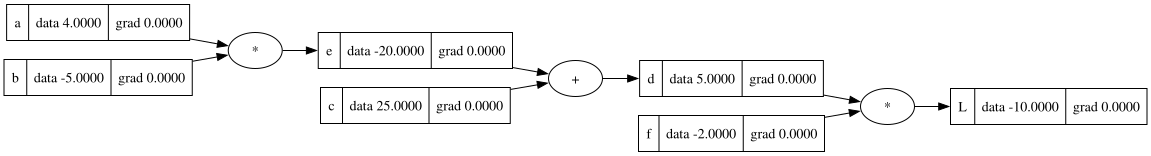

In [15]:
draw_dot(L)

In [16]:
L.grad = 1.00
f.grad = 5.00
d.grad = -2.00

In [17]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

# Backprpogation ( doing dervatives )

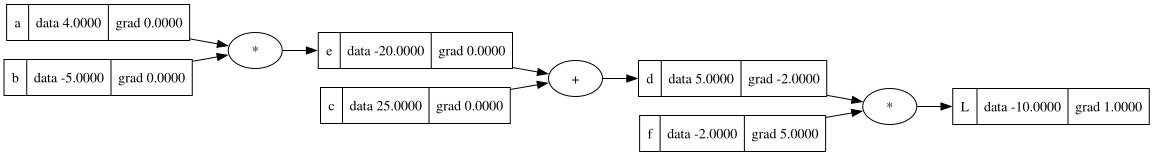

In [18]:
draw_dot(L)

## #dL/df

In [19]:
def lol():
    h = 0.00001
    a = value(4.0,label = 'a')      
    b = value(-5.0,label = 'b')
    c = value(25, label ='c')

    e= a*b ; e.label = 'e'

    d = e + c ; d.label = 'd' # it will internally calls like : (a.__mul__(b)).__add__(c)
    f = value(-2.0,label ='f')
    L = d*f ; L.label = 'L'
    L1 = L.data

    a = value((4.0), label = 'a')
    b = value(-5.0,label = 'b')
    c = value(25,label = 'c')

    e = a*b ; e.label = 'e'
    d = e + c ; d.label = 'd'
    f = value(-2.0+h,label = 'f') # -2.0+h i.e.  taking derivatives with respect to f 

    L = d*f ; L.label = 'L'

    L2 = L.data

    print((L2-L1)/h) # ((f+h)-f)/h
lol()

4.999999999988347


## # dL/dd

In [20]:
def lol():
    h = 0.00001
    a = value(4.0,label = 'a')      
    b = value(-5.0,label = 'b')
    c = value(25, label ='c')

    e= a*b ; e.label = 'e'

    d = e + c ; d.label = 'd' # it will internally calls like : (a.__mul__(b)).__add__(c)
    f = value(-2.0,label ='f')
    L = d*f ; L.label = 'L'
    L1 = L.data

    a = value((4.0), label = 'a')
    b = value(-5.0,label = 'b')
    c = value(25,label = 'c')

    e = a*b ; e.label = 'e'
    d = e + c ; d.label = 'd'
    d.data +=h # d = d+h , 
    f = value(-2.0,label = 'f')

    L = d*f ; L.label = 'L'

    L2 = L.data

    print((L2-L1)/h) # ((d+h)-d)/h
lol()

-1.9999999999242843


In [21]:
def lol():
    h = 0.00001
    a = value(4.0,label = 'a')      
    b = value(-5.0,label = 'b')
    c = value(25, label ='c')

    e= a*b ; e.label = 'e'

    d = e + c ; d.label = 'd' # it will internally calls like : (a.__mul__(b)).__add__(c)
    f = value(-2.0,label ='f')
    L = d*f ; L.label = 'L'
    L1 = L.data

    a = value((4.0+h), label = 'a')
    b = value(-5.0,label = 'b')
    c = value(25,label = 'c')

    e = a*b ; e.label = 'e'
    d = e + c ; d.label = 'd'
    f = value(-2.0,label = 'f')

    L = d*f ; L.label = 'L'

    L2 = L.data

    print((L2-L1)/h)
lol()



    

    


9.999999999621423


# Numerical Gradient — Simple Explanation

The purpose of this code is to **check how much the final output `L` changes when we slightly change `a`**.

Our equation is:

    L = (a × b + c) × f

---

## 1. Create a very small change

    h = 0.00001

### Why?

We want to change `a` by a **very tiny amount**.

    a = 4
    a + h = 4.00001

This helps us measure how sensitive `L` is to `a`.

---

## 2. Calculate the original `L`

    a = value(4.0, label='a')
    b = value(-5.0, label='b')
    c = value(25, label='c')

    e = a * b
    d = e + c

    f = value(-2.0, label='f')
    L = d * f

    L1 = L.data

Calculation:

    e = 4 × (-5) = -20

    d = -20 + 25 = 5

    L = 5 × (-2) = -10

So:

    L1 = -10

### Why?

We need the **original output** so that we can compare it with the new output.

---

## 3. Increase `a` slightly

    a = value(4.0 + h, label='a')

Now:

    a = 4.00001

The other values stay the same.

### Why?

We want to see:

> "What happens to `L` if I make a tiny change to `a`?"

---

## 4. Calculate `L` again

    e = a * b
    d = e + c
    f = value(-2.0, label='f')
    L = d * f

    L2 = L.data

Now we get approximately:

    L2 = -9.9999

So:

    Before changing a:  L1 = -10
    After changing a:   L2 = -9.9999

---

## 5. Calculate the gradient

    print((L2 - L1) / h)

This is the **finite difference formula**:

    gradient ≈ (new output - old output) / change

So:

    dL/da ≈ (L2 - L1) / h

Result:

    ≈ 10

### Why?

This tells us how strongly `L` changes when `a` changes.

So we learned:

    dL/da ≈ 10

---

# Now Start Backpropagation

We have:

    L = d × f

and:

    d = 5
    f = -2

---

## 6. Start with `L.grad`

    L.grad = 1.0

### Why 1?

Because:

    dL/dL = 1

A value's derivative with respect to itself is always `1`.

This is where backpropagation starts.

---

## 7. Find `d.grad`

We have:

    L = d × f

Derivative with respect to `d`:

    dL/dd = f

We know:

    f = -2

Therefore:

    d.grad = -2

### Why?

If `d` changes by 1, `L` changes by `f`.

Since:

    f = -2

`L` changes by `-2`.

---

## 8. Find `f.grad`

For:

    L = d × f

Derivative with respect to `f`:

    dL/df = d

We know:

    d = 5

Therefore:

    f.grad = 5

### Why?

If `f` changes by 1, `L` changes by `d`.

Since:

    d = 5

`L` changes by `5`.

---

# Final Result

    L.grad = 1
    d.grad = -2
    f.grad = 5

Think of the process as:

    Forward:
    
    a → e → d → L
              ↑
              f

    Backward:

    L.grad = 1
       ↓
    d.grad = -2
    f.grad = 5

---

# Why are we doing all this?

We are preparing Micrograd for **automatic differentiation**.

First, we manually understand gradients:

    Numerical method
    → change a slightly
    → observe change in L
    → calculate dL/da

Then we start:

    Backpropagation
    → start at L
    → move backward
    → calculate gradients

Later, Micrograd will do this **automatically** for us.

# Key Takeaway

    (L2 - L1) / h
            ↓
    numerical gradient of a

    L.grad = 1
            ↓
    start backpropagation

    d.grad = -2
    f.grad = 5
            ↓
    move further backward through the graph

### # Now Crux of backpropogation 

In [22]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

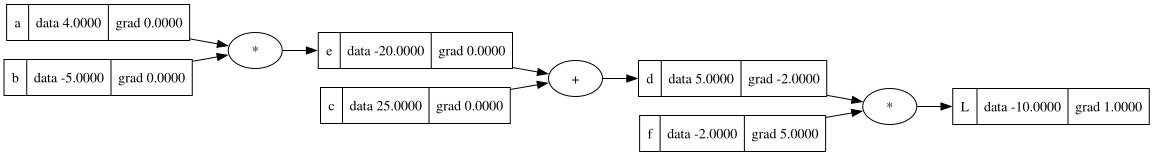

In [23]:
draw_dot(L)

In [24]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

dd / dc ? 1.0

d = c + e

(f(x+h) - f(x)) / h

((c + h + e) - (c + e)) / h

(c + h + e - c - e) / h

h / h

1.0

# looking for local derivative i.e. , dL / dc and dL / de

# using chain rule 

dd/dc = 1 = dd / de 

WANT : 

dL / dc = (dL / dd) * (dd / dc)

dL / dc = (-2.0)*(1.0)

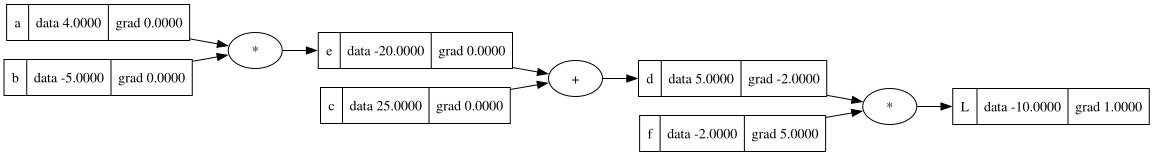

In [25]:
draw_dot(L)

In [26]:
c.grad = -2.0
e.grad = -2.0

In [27]:
# now checking via code of gradient descent of c.grad and e.grad 

# for c.grad

def lol():
    h = 0.00001
    a = value(4.0,label = 'a')      
    b = value(-5.0,label = 'b')
    c = value(25, label ='c')

    e= a*b ; e.label = 'e'

    d = e + c ; d.label = 'd' # it will internally calls like : (a.__mul__(b)).__add__(c)
    f = value(-2.0,label ='f')
    L = d*f ; L.label = 'L'
    L1 = L.data

    a = value((4.0), label = 'a')
    b = value(-5.0,label = 'b')
    c = value(25,label = 'c')
    c.data +=h # c = c+h 

    e = a*b ; e.label = 'e'

    d = e + c ; d.label = 'd'
    f = value(-2.0,label = 'f')

    L = d*f ; L.label = 'L'

    L2 = L.data

    print((L2-L1)/h) # dL / dc = ((c+h)-c)/h
    # simillarly for e, e.data +=h
lol()

-1.9999999999242843


# now again apply chain rule for grad. of 'a' and 'b'. 

we have dL / de = -2.0 

WANT : 

dL / da ? ;  #.             

 dL / da = (dL / de) * (de / da) 

as we have (dL/de) = -2.0

now finding (de / da ) ?

e = a * b 

e = ( 2.0 ) * ( -3.0 )

de / da ? ; b ( as we have done earlier )


so de / da = - 3.0 

hence dL / da = (dL / de ) * (de / da)

______dL / da =  ( -2.0 ) *  ( -3.0 ) __ = __ + 6

simillarly for 

______dL / db = ( -2.0 ) * ( 2.0 ) = -4.0 





In [28]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

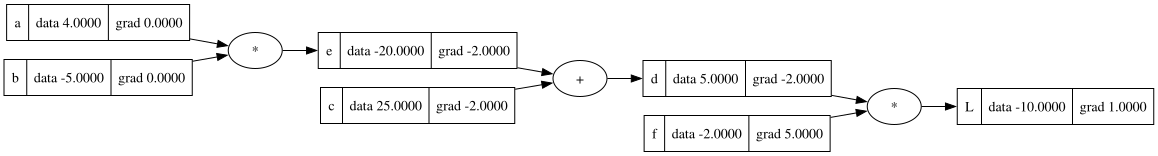

In [29]:
draw_dot(L)

In [30]:
a.grad = 6.0 
b.grad = -4.0 

In [31]:
# now checking via code of gradient descent of a.grad and b.grad 

# for a.grad

def lol():
    h = 0.00001
    a = value(4.0,label = 'a')      
    b = value(-5.0,label = 'b')
    c = value(25, label ='c')

    e= a*b ; e.label = 'e'

    d = e + c ; d.label = 'd' # it will internally calls like : (a.__mul__(b)).__add__(c)
    f = value(-2.0,label ='f')
    L = d*f ; L.label = 'L'
    L1 = L.data

    a = value((4.0), label = 'a')
    a.data +=h
    b = value(-5.0,label = 'b')
    c = value(25,label = 'c')
    # c.data +=h # c = c+h 

    e = a*b ; e.label = 'e'

    d = e + c ; d.label = 'd'
    f = value(-2.0,label = 'f')

    L = d*f ; L.label = 'L'

    L2 = L.data

    print((L2-L1)/h) # dL / dc = ((c+h)-c)/h
    # simillarly for e, e.data +=h
lol()

9.999999999621423


## Manual Backpropogation # example : 02

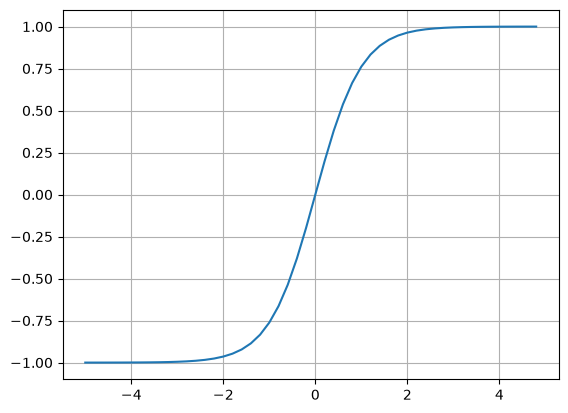

In [32]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid()

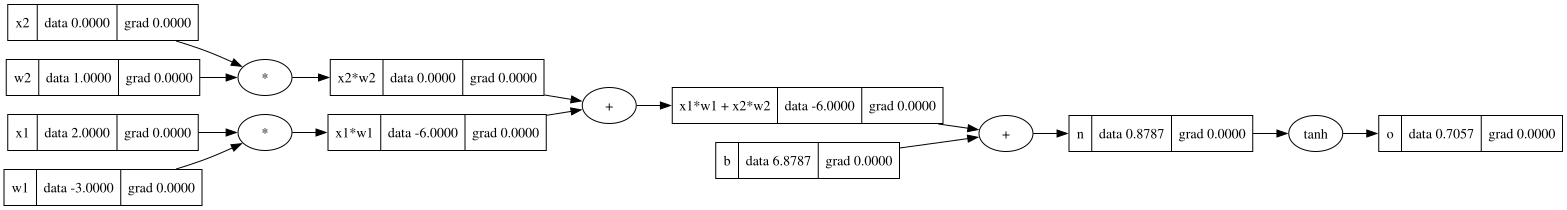

In [33]:
# input x1 and x2 
x1 = value(2.0, label='x1')
x2 = value(0.0, label='x2')

# weight w1 and w2 
w1 = value(-3.0, label='w1')
w2 = value(1.0, label='w2')

# bais of the neuron 
b  = value(6.8786564646, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1;  x1w1.label = 'x1*w1'
x2w2 = x2*w2;  x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label='x1*w1 + x2*w2'
n = x1w1x2w2 + b;  n.label = 'n'
o = n.tanh();      o.label = 'o'

draw_dot(o)

### Hyperbolic Tangent ,  # Tanh()

$$
\tanh(x) = \frac{e^{2x} - 1}{e^{2x} + 1}
$$

### Derivative of tanh

$$
\frac{d}{dx}\tanh(x) = 1 - \tanh^2(x)
$$

Since:

$$
t = \tanh(x)
$$

we can write:

$$
\frac{dt}{dx} = 1 - t^2
$$

### Backpropagation

$$
\frac{\partial L}{\partial x}
=
(1-t^2)
\frac{\partial L}{\partial t}
$$

---

### For Our Specific Example

We have:

$$
o = \tanh(n)
$$

Therefore:

$$
\frac{do}{dn}
=
\frac{d(\tanh(n))}{dn}
$$

Using the derivative of tanh:

$$
\frac{do}{dn}
=
1 - \tanh^2(n)
$$

Since:

$$
o = \tanh(n)
$$

therefore:

$$
\boxed{\frac{do}{dn} = 1 - o^2}
$$

For backpropagation:

$$
n.grad
=
(1-o^2) \times o.grad
$$

In [34]:
o.grad = 1 # as do / do = 1

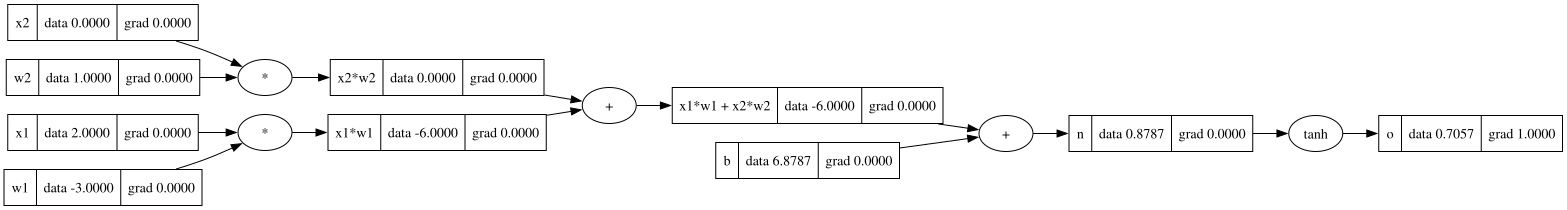

In [35]:
draw_dot(o)

For backpropagation:

$$
n.grad
=
(1-o^2) \times o.grad
$$


for n.grad __ i.e. __ do/dn 

In [36]:
o.data

0.7057456081105479

In [37]:
n.grad = (1 - o.data**2)*(1) # as o.grad = 1 
n.grad

0.501923136632673

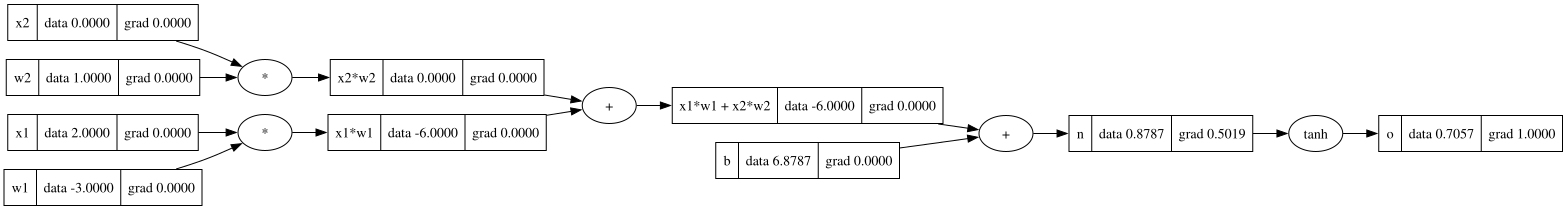

In [38]:
draw_dot(o)

In [39]:
# now for x1w1x2w2;
#. as we seen earlier for addition gradient is distributed equally so ; 

# as n = x1w1x2w2 + b and n.grad = 0.501923136632673 so ;

x1w1x2w2.grad = 0.501923136632673
b.grad = 0.501923136632673



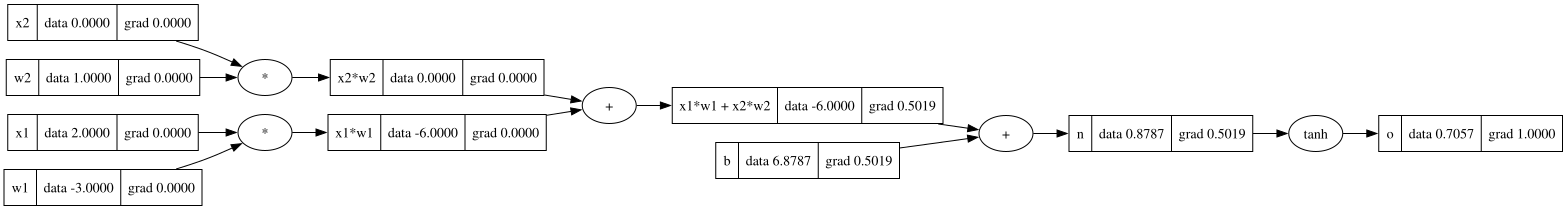

In [40]:
draw_dot(o)

In [41]:
# simillarly as x1w1x2w2 = x1w1 + x2w2 ; so ,grad will be equally distributed on them too 
x1w1.grad = 0.501923136632673
x2w2.grad = 0.501923136632673


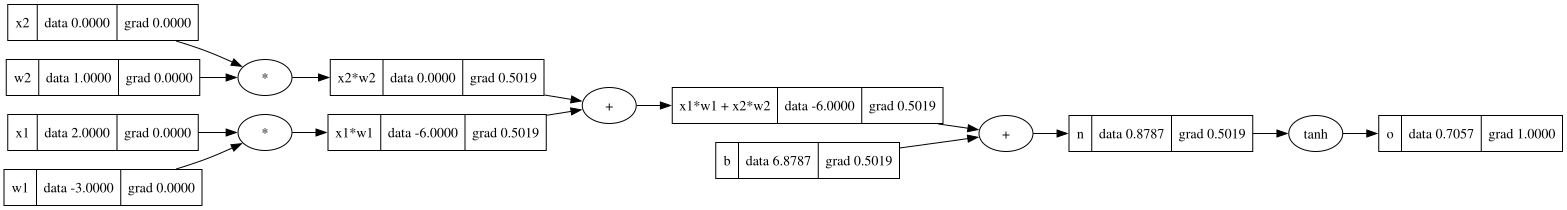

In [42]:
draw_dot(o)

### Backpropagation to `x1`

$$
\frac{do}{dx_2}
=
\frac{do}{dn}
\times
\frac{dn}{d(x_2w_2)}
\times
\frac{d(x_2w_2)}{dx_2}
$$

$$
\frac{do}{dx_2}
=
(1-o^2)\times1\times w_2
$$

Therefore:

$$
\boxed{x_2.grad = w_2.data\times x_2w_2.grad}
$$

---

### Backpropagation to `w2`

$$
\frac{do}{dw_2}
=
\frac{do}{dn}
\times
\frac{dn}{d(x_2w_2)}
\times
\frac{d(x_2w_2)}{dw_2}
$$

$$
\frac{do}{dw_2}
=
(1-o^2)\times1\times x_2
$$

Therefore:

$$
\boxed{w_2.grad = x_2.data\times x_2w_2.grad}
$$

$$
\boxed{x_2.grad = w_2.data \times x_2w_2.grad}
$$

$$
\boxed{w_2.grad = x_2.data \times x_2w_2.grad}
$$

In [43]:
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad


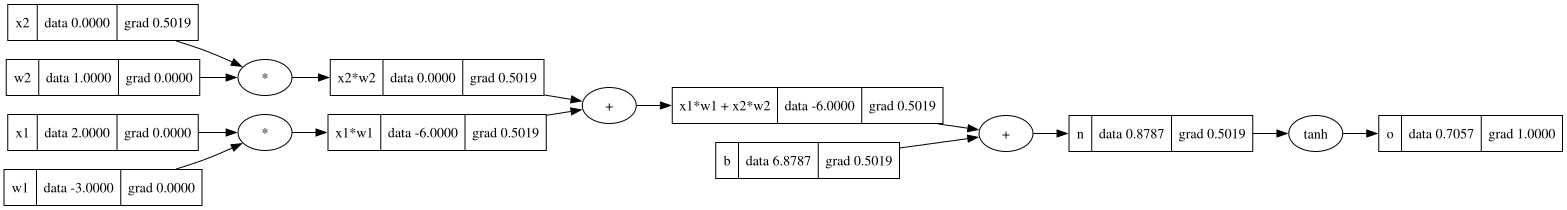

In [44]:
draw_dot(o)

# simillarly 
$$
\boxed{x_1.grad = w_1.data \times x_1w_1.grad}
$$

$$
\boxed{w_1.grad = x_1.data \times x_1w_1.grad}
$$

In [45]:
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad


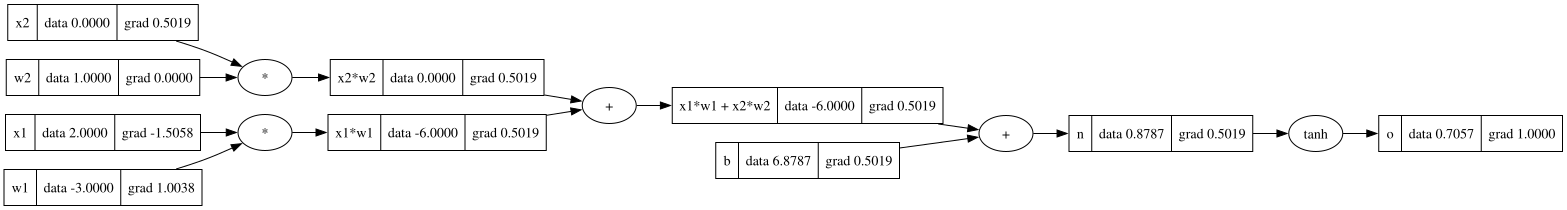

In [46]:
draw_dot(o)

# # Automatic Backpropogation 

In [47]:
class value :
    def __init__(self,data, _children=(),_op='',label=''):
        self.data = data 
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0
        self._backward = lambda:None
    def __repr__(self):
        return f"value(data={self.data})"    # data is a number 


    def __add__(self,other): # doing it becoz python does not know how to add two values 
        out = value(self.data + other.data,(self,other),'+')   
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward
        return out    

    # simillarly doing for multiplication 
    def __mul__(self,other):
        out = value(self.data * other.data,(self,other),'*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * other.grad

        out._backward = _backward    
        return out    

# Activating tanh() function 
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1-t**2) * out.grad
        out._backward = _backward   
        return out
# Automatic backpropogation 

    # def _backward():
    #     self.grad += (1 - t**2) * out.grad
    #     out._backward = _backward
    #     return out

a = value(4.0,label = 'a')      
b = value(-5.0,label = 'b')
c = value(25, label ='c')

e= a*b ; e.label = 'e'

d = e +c ; d.label = 'd' # it will internally calls like : (a.__mul__(b)).__add__(c)
f = value(-2.0,label ='f')
L = d*f ; L.label = 'L'
L

value(data=-10.0)

In [48]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [49]:
# input x1 and x2 
x1 = value(2.0, label='x1')
x2 = value(0.0, label='x2')

# weight w1 and w2 
w1 = value(-3.0, label='w1')
w2 = value(1.0, label='w2')

# bais of the neuron 
b  = value(6.8786564646, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1;  x1w1.label = 'x1*w1'
x2w2 = x2*w2;  x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label='x1*w1 + x2*w2'
n = x1w1x2w2 + b;  n.label = 'n'
o = n.tanh();      o.label = 'o'


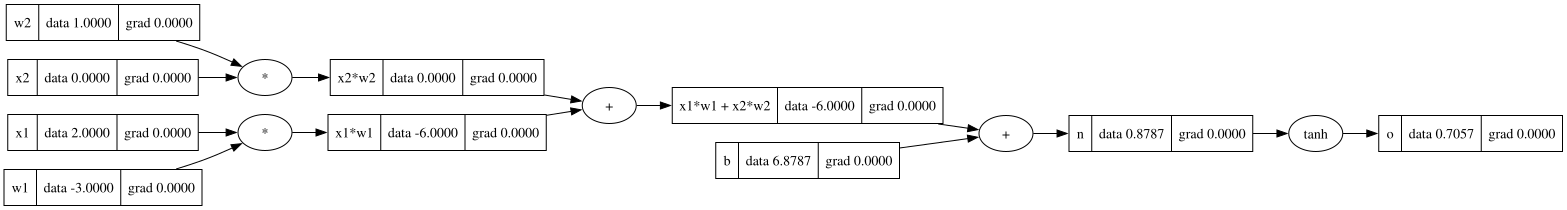

In [50]:
draw_dot(o)

In [51]:
o.grad = 1

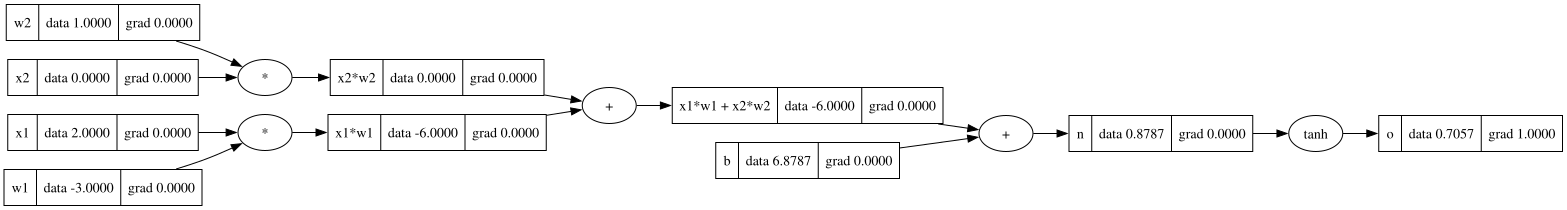

In [52]:
draw_dot(o)

In [53]:
o._backward() # to automatic calculate backpropogation of o

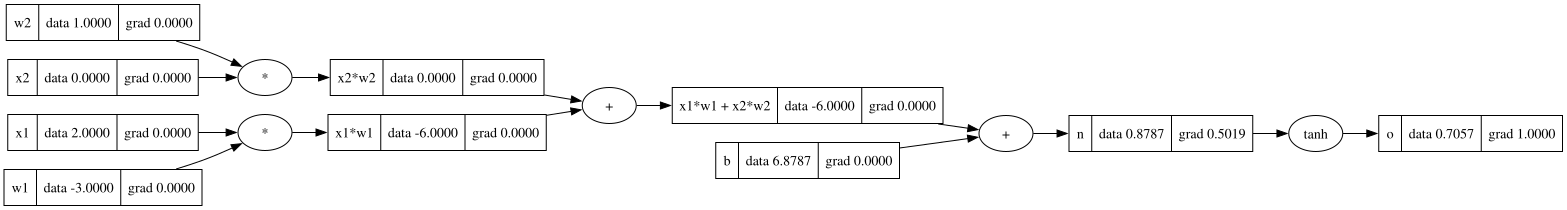

In [54]:
draw_dot(o)

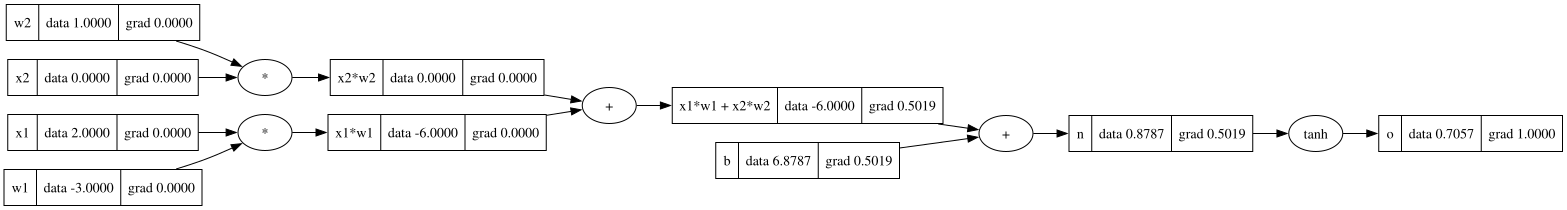

In [55]:
n._backward() # to automatic calculate backpropogation of n
draw_dot(o)

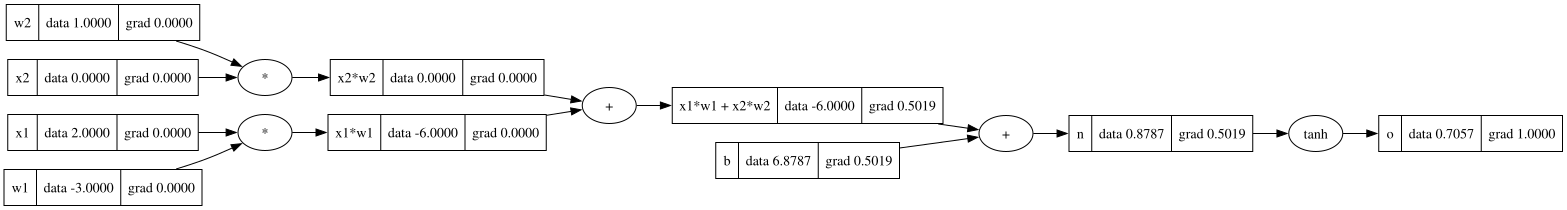

In [56]:
b._backward() # to automatic calculate backpropogation of b
draw_dot(o) # b will not show any changes as b is a leaf node and we set b as none for leaf node (empty function)

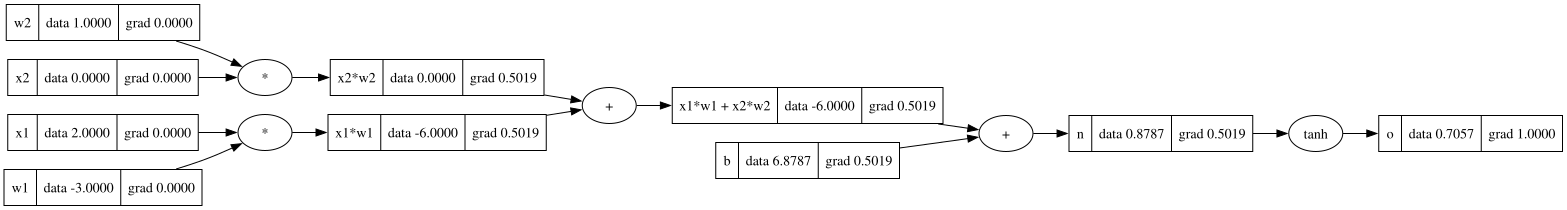

In [57]:
x1w1x2w2._backward() # to automatic calculate backpropogation of x1w1x2w2
draw_dot(o)

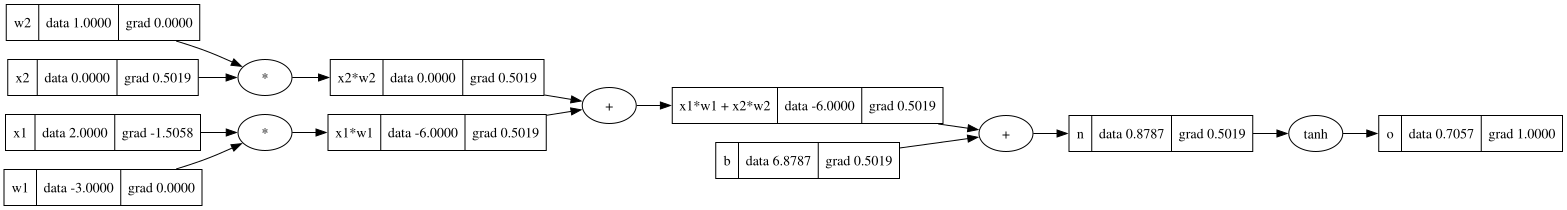

In [58]:
x1w1._backward()
x2w2._backward() # to automatic calculate backpropogation of x1w1x2w2
draw_dot(o)